### $$2D~Voltage~Sweep$$

This notebook is the first test of a 2D voltage sweep using Q1ASM in Qblox since Luke and Noah in the Summer of 2024. In general, it is useful to have fast control of multiple gates and gate voltages at once. Preforming our loops using Qblox, however, will yield significantly faster results than looping through voltage values in SA. This is demonstrated below.

Author: Ben Van Osch (Updated: 04/01/2025) 

First, we import anything relevant:

In [13]:
# Imports
import time
import matplotlib.pyplot as plt
import pyvisa
import numpy as np
from __future__ import annotations 
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument
from qblox_instruments import Cluster, ClusterType
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module
import sys
sys.path.append(r"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Libraries\\Qblox Sequence Helpers")
import sequence_helperV2 as sh

In [ ]:
!qblox-pnp list

Then, we connect to the Qblox cluster and the Oscilloscope:

In [14]:
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    name=cluster_name,
    recreate=True,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'
# Get modules, and connect to the QRM
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True
    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]
cluster.reset()
print(cluster.get_system_status())
qrm_module = modules[4]
qcm_module = modules[2]
rf_module = modules[6]
rm = pyvisa.ResourceManager()
#scope = rm.open_resource('GPIB0::8::INSTR')

Status: OKAY, Flags: NONE, Slot flags: NONE


Here, we specify parameters for the oscilloscope display. You can change these much more easily here than manually with the oscilloscope:

In [ ]:
# Setting the oscilloscope ranges

scope.write(f'TIME_DIV {100e-4} S')	# Set the time scale on all oscilloscope channels
scope.write(f'C1:VOLT_DIV {1.0} V')	    # Set the voltage scale on channel 1
scope.write(f'C2:VOLT_DIV {1.0} V')	    # Set the voltage scale on channel 2
scope.write(f'C3:VOLT_DIV {1.0} V')	    # Set the voltage scale on channel 2
scope.write(f'C4:VOLT_DIV {1.0} V')	    # Set the voltage scale on channel 2
scope.write(f'TRIG_DELAY {0}')			# Set the time scale left/right on the display
scope.write(f'TRIG_MODE NORMAL')		# Set the trigger mode to "single" in order to take one acquisition

Now, using the sequence helper library, we create our sequences. Since we want a 2D voltage sweep, we first need to define a waveform . Though, we have to ensure that the first loop is played again each time the second loop takes a voltage step:

In [ ]:
# First, we define an empty output seqeunce, basically an empty list. We also define our voltage sweep parameters

output_seq_0 = []

num_steps = 200

num_list = range(0,num_steps)

stepsize = 10e-3 # 10 mV steps

# Now, we define our first output sequence as sequential ramps one after the other

output_seq_0.append(['ramp',num_steps,0.0,1.0])

output_seq_0 *= num_steps

print(len(output_seq_0))
print(output_seq_0)

# Now, we need to define our second output sequence 

output_seq_1 = []

for i, val in enumerate(num_list):
	output_seq_1.append(['square', num_steps, val*stepsize/2])

print(len(output_seq_1))
print(output_seq_1)

Now, we have to specify the aqcuisition parameters:

In [ ]:
input_seq_0 = ['acq_0', 0, 41e3] # This is much simpler than output seqeunces, since we only need to specify start time and duration
input_seq_1 = ['acq_1', 0, 41e3]

# We also must set an input gain, since the QRM increases the strength of inputs by 10%
input_gain = -1

Now that we have our sequences ready, we upload them to the cluster and play them:

In [ ]:
#First, we disconnect any prexisting connections

sh.disconnect_io(qcm_module)
sh.disconnect_io(qrm_module)

# Now, we upload our sequences to the modules and specify sequencers

qcm_module.sequencer0.sequence(sh.make_output_sequence(output_seq_0, module = "qcm"))
qcm_module.sequencer1.sequence(sh.make_output_sequence(output_seq_1, module = "qcm"))
qrm_module.sequencer0.sequence(sh.make_input_sequence(input_seq_0))
qrm_module.sequencer1.sequence(sh.make_input_sequence(input_seq_1))

# Now, we connect the modules to the sequencers

qcm_module.sequencer0.connect_out0("I")
qcm_module.sequencer1.connect_out1("I")
sh.connect_input(module = qrm_module, sequencer = 0, input_index = 0, path = 0)
sh.connect_input(module = qrm_module, sequencer = 1, input_index = 1, path = 0)

# The QRM has a built-in amplifier, so this is here to offset this. It also has an offset, which is corrected here.

qrm_module.in0_gain(input_gain)
qrm_module.in1_gain(input_gain)
qrm_module.in0_offset(-1e-3)
qrm_module.in1_offset(-1e-3)

# Then, we enable the sync protocol for all sequencers

qcm_module.sequencer0.sync_en(True)
qcm_module.sequencer1.sync_en(True)
qrm_module.sequencer0.sync_en(True)
qrm_module.sequencer1.sync_en(True)

# Here we arm the sequencers

qcm_module.arm_sequencer(0)
qcm_module.arm_sequencer(1)
qrm_module.arm_sequencer(0)
qrm_module.arm_sequencer(1)

# This next step runs the sequences we loaded

cluster.start_sequencer()

# Then, we stop the sequencers

qcm_module.stop_sequencer(0)
qcm_module.stop_sequencer(1)
qrm_module.stop_sequencer(0)
qrm_module.stop_sequencer(1)

We can then use the plot_input() and/or plot_input_multi() functions to plot the aqcuisition we've stored:

In [ ]:
sh.plot_input_multi(module = qrm_module, sequencers = [0,1], acquisition_names = ['acq_0','acq_1'])

Below is a second version of the 2D sweep, but this time, instead of each point being held for one nanosecond, each point will be held for 1 microsecond:

In [5]:
# First, we define an empty output seqeunce, basically an empty list. We also define our voltage sweep parameters

output_seq_0 = []

num_steps = 200 

ramp_duration = num_steps*1000 # 200 steps, each taking 1000 ns = 1 us

num_list = range(0,num_steps)

stepsize = 10e-3 # 10 mV steps

# Now, we define a loop over which we add all the square pulses to the output sequence

output_seq_0.append(['ramp',ramp_duration,0.0,1.0])

print(len(output_seq_0))
print(output_seq_0)

# Now, we need to define our second output sequence

output_seq_1 = []

for i, val in enumerate(num_list):
	output_seq_1.append(['square',ramp_duration, val*stepsize/2])

print(len(output_seq_1))
print(output_seq_1)

input_seq_0 = ['acq_0', 0, 40e6]
input_seq_1 = ['acq_1', 0, 40e6]

input_gain = -6

1
[['ramp', 200000, 0.0, 1.0]]
200
[['square', 200000, 0.0], ['square', 200000, 0.005], ['square', 200000, 0.01], ['square', 200000, 0.015], ['square', 200000, 0.02], ['square', 200000, 0.025], ['square', 200000, 0.03], ['square', 200000, 0.035], ['square', 200000, 0.04], ['square', 200000, 0.045], ['square', 200000, 0.05], ['square', 200000, 0.055], ['square', 200000, 0.06], ['square', 200000, 0.065], ['square', 200000, 0.07], ['square', 200000, 0.075], ['square', 200000, 0.08], ['square', 200000, 0.085], ['square', 200000, 0.09], ['square', 200000, 0.095], ['square', 200000, 0.1], ['square', 200000, 0.105], ['square', 200000, 0.11], ['square', 200000, 0.115], ['square', 200000, 0.12], ['square', 200000, 0.125], ['square', 200000, 0.13], ['square', 200000, 0.135], ['square', 200000, 0.14], ['square', 200000, 0.145], ['square', 200000, 0.15], ['square', 200000, 0.155], ['square', 200000, 0.16], ['square', 200000, 0.165], ['square', 200000, 0.17], ['square', 200000, 0.17500000000000002]

Now that we have our sequences ready, we upload them to the cluster and play them:

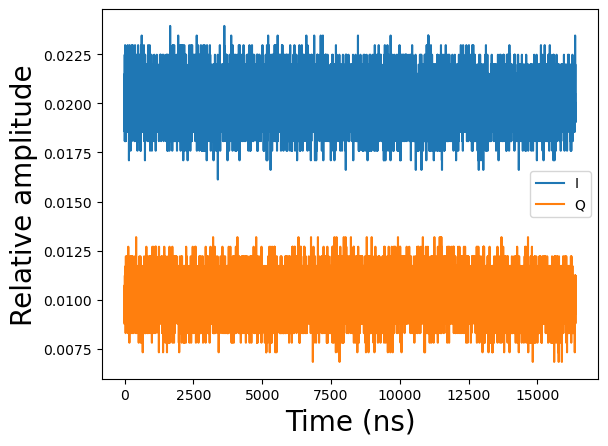

I Offset : 20.078 mV 
Q Offset : 10.249 mV
resolution for qcm output: 33 ns
resolution for qcm output: 8 ns
Input sequence:
		move 		0,R0
		move		40000,R1
		wait_sync	4
		wait		150
	loop:
		acquire		0,R0,1000
		add		R0,1,R0
		loop		R1,@loop
		stop
Input sequence:
		move 		0,R0
		move		40000,R1
		wait_sync	4
		wait		150
	loop:
		acquire		0,R0,1000
		add		R0,1,R0
		loop		R1,@loop
		stop


In [6]:
#First, we disconnect any prexisting connections

sh.disconnect_io(qcm_module)
sh.disconnect_io(qrm_module)

I_offset, Q_offset = sh.acquire_scope_and_calc_offsets(qrm_module)

sh.disconnect_io(qcm_module)
sh.disconnect_io(qrm_module)

# Now, we upload our sequences to the modules and specify sequencers

qcm_module.sequencer0.sequence(sh.make_output_sequence(output_seq_0, module = "qcm", iterations = 200))
qcm_module.sequencer1.sequence(sh.make_output_sequence(output_seq_1, module = "qcm"))
qrm_module.sequencer0.sequence(sh.make_input_sequence(input_seq_0, resolution = 1000))
qrm_module.sequencer1.sequence(sh.make_input_sequence(input_seq_1, resolution = 1000))

# Now, we connect the modules to the sequencers

qcm_module.sequencer0.connect_out0("I")
qcm_module.sequencer1.connect_out1("I")
sh.connect_input(module = qrm_module, sequencer = 0, input_index = 0, path = 0, resolution = 1000)
sh.connect_input(module = qrm_module, sequencer = 1, input_index = 1, path = 0, resolution = 1000)

# The QRM has a built-in amplifier, so this is here to offset this. It also has an offset, which is corrected here.

time.sleep(5)

qrm_module.in0_gain(input_gain)
qrm_module.in1_gain(input_gain)
qrm_module.in0_offset(-I_offset)
qrm_module.in1_offset(-Q_offset)

# Then, we enable the sync protocol for all sequencers

qcm_module.sequencer0.sync_en(True)
qcm_module.sequencer1.sync_en(True)
qrm_module.sequencer0.sync_en(True)
qrm_module.sequencer1.sync_en(True)

# Here we arm the sequencers

qcm_module.arm_sequencer(0)
qcm_module.arm_sequencer(1)
qrm_module.arm_sequencer(0)
qrm_module.arm_sequencer(1)

# This next step runs the sequences we loaded

cluster.start_sequencer()

"""
Now, since the pulse duration is longer than the time it takes to start and stop the sequencers, 
we need to wait to give the sequence time to play
"""

time.sleep(5) # 5 seconds was an arbitrary choice, as long as this time is longer than the sequence length it should be fine

# Now, we stop the sequencers

qcm_module.stop_sequencer(0)
qcm_module.stop_sequencer(1)
qrm_module.stop_sequencer(0)
qrm_module.stop_sequencer(1)

Again, we plot the input into the QRM:

resolution in plot_input: 1000


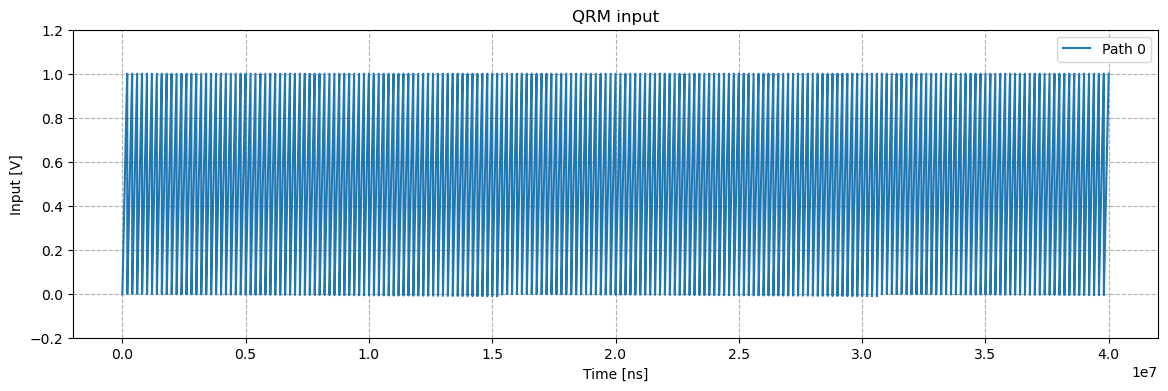

resolution in plot_input: 1000


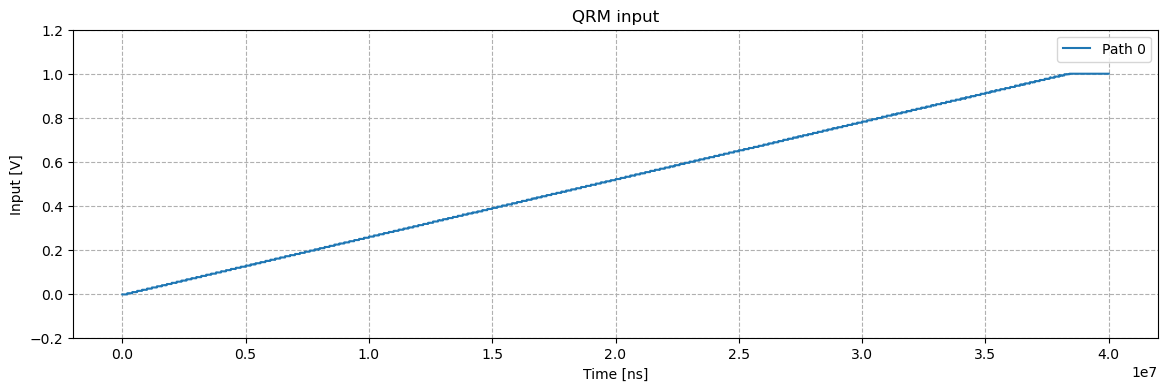

40000
40000
resolution in plot_input: 1000


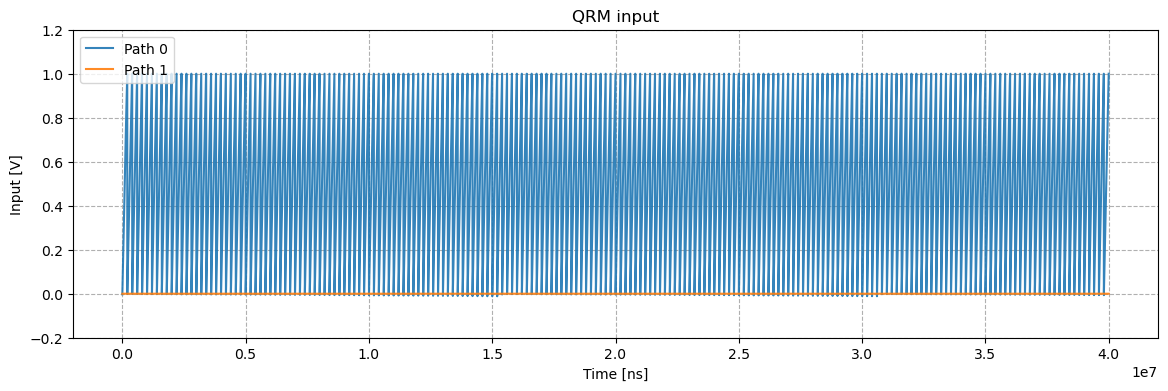

resolution in plot_input: 1000


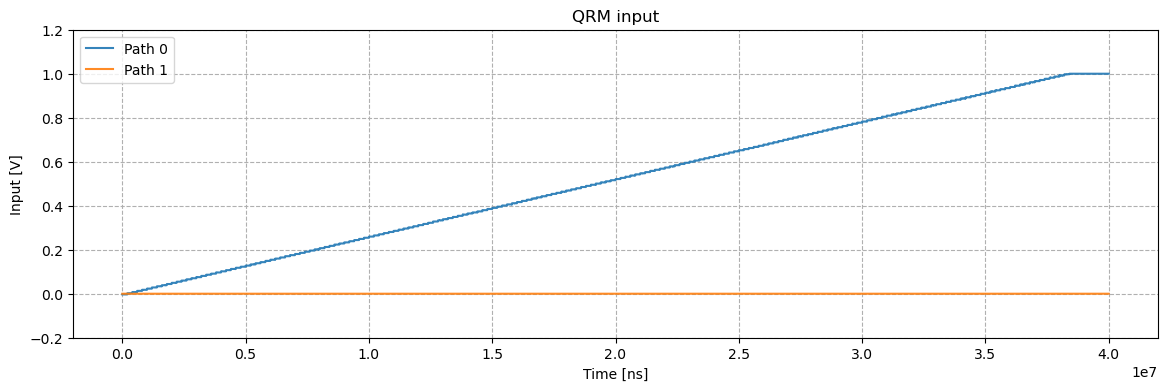

In [7]:
sh.plot_input(module = qrm_module, sequencer = 0, acquisition_name ='acq_0')
sh.plot_input(module = qrm_module, sequencer = 1, acquisition_name ='acq_1')
sh.plot_input_multi(module = qrm_module, sequencers = [0,1], acquisition_names = ['acq_0','acq_1'])

Now, for a third edition of the sweep, let's test to see if we can perform the same 1 microsecond sweep from before with just square pulses:

In [10]:
# First, we define an empty output seqeunce, basically an empty list. We also define our voltage sweep parameters

output_seq_0 = []

num_steps = 200 

ramp_duration = num_steps*1000 # 200 steps, each taking 1000 ns = 1 us

num_list = range(0,num_steps)

stepsize = 10e-3 # 10 mV steps

# Now, we define a loop over which we add all the square pulses to the output sequence
for i, val in enumerate(num_list):
	output_seq_0.append(['square', ramp_duration/num_steps, val*stepsize/2])

print(len(output_seq_0))
print(output_seq_0)

# Now, we need to define our second output sequence

output_seq_1 = []

for i, val in enumerate(num_list):
	output_seq_1.append(['square', ramp_duration, val*stepsize/2])

print(len(output_seq_1))
print(output_seq_1)

input_seq_0 = ['acq_0', 0, 40e6]
input_seq_1 = ['acq_1', 0, 40e6]

input_gain = -6

200
[['square', 1000.0, 0.0], ['square', 1000.0, 0.005], ['square', 1000.0, 0.01], ['square', 1000.0, 0.015], ['square', 1000.0, 0.02], ['square', 1000.0, 0.025], ['square', 1000.0, 0.03], ['square', 1000.0, 0.035], ['square', 1000.0, 0.04], ['square', 1000.0, 0.045], ['square', 1000.0, 0.05], ['square', 1000.0, 0.055], ['square', 1000.0, 0.06], ['square', 1000.0, 0.065], ['square', 1000.0, 0.07], ['square', 1000.0, 0.075], ['square', 1000.0, 0.08], ['square', 1000.0, 0.085], ['square', 1000.0, 0.09], ['square', 1000.0, 0.095], ['square', 1000.0, 0.1], ['square', 1000.0, 0.105], ['square', 1000.0, 0.11], ['square', 1000.0, 0.115], ['square', 1000.0, 0.12], ['square', 1000.0, 0.125], ['square', 1000.0, 0.13], ['square', 1000.0, 0.135], ['square', 1000.0, 0.14], ['square', 1000.0, 0.145], ['square', 1000.0, 0.15], ['square', 1000.0, 0.155], ['square', 1000.0, 0.16], ['square', 1000.0, 0.165], ['square', 1000.0, 0.17], ['square', 1000.0, 0.17500000000000002], ['square', 1000.0, 0.18], ['s

Now, we prepare our sequencers, using the new square pulse only function:

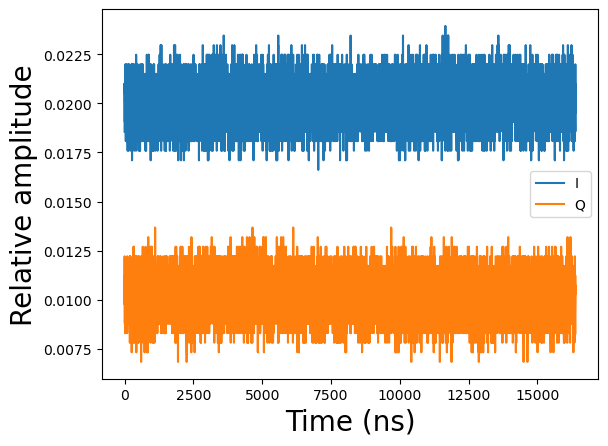

I Offset : 19.996 mV 
Q Offset : 10.244 mV
The number of commands in the sequence is: 800
Input sequence:
		move 		0,R0
		move		40000,R1
		wait_sync	4
		wait		150
	loop:
		acquire		0,R0,1000
		add		R0,1,R0
		loop		R1,@loop
		stop
Input sequence:
		move 		0,R0
		move		40000,R1
		wait_sync	4
		wait		150
	loop:
		acquire		0,R0,1000
		add		R0,1,R0
		loop		R1,@loop
		stop


In [11]:
#First, we disconnect any prexisting connections

sh.disconnect_io(qcm_module)
sh.disconnect_io(qrm_module)

I_offset, Q_offset = sh.acquire_scope_and_calc_offsets(qrm_module) # This has to happen before any other command sends a sequence to the seqeuncer.

sh.disconnect_io(qcm_module)
sh.disconnect_io(qrm_module)

# Now, we upload our sequences to the modules and specify sequencers

qcm_module.sequencer0.sequence(sh.make_output_sequence_square(output_seq_0, module = "qcm", iterations = 200))
qcm_module.sequencer1.sequence(sh.make_output_sequence_square(output_seq_1, module = "qcm"))
qrm_module.sequencer0.sequence(sh.make_input_sequence(input_seq_0, resolution = 1000))
qrm_module.sequencer1.sequence(sh.make_input_sequence(input_seq_1, resolution = 1000))

# Now, we connect the modules to the sequencers

qcm_module.sequencer0.connect_out0("I")
qcm_module.sequencer1.connect_out1("I")
sh.connect_input(module = qrm_module, sequencer = 0, input_index = 0, path = 0, resolution = 1000)
sh.connect_input(module = qrm_module, sequencer = 1, input_index = 1, path = 0, resolution = 1000)

# The QRM has a built-in amplifier, so this is here to offset this. It also has an offset, which is corrected here.

qrm_module.in0_gain(input_gain)
qrm_module.in1_gain(input_gain)
qrm_module.in0_offset(-I_offset)
qrm_module.in1_offset(-Q_offset)

# Then, we enable the sync protocol for all sequencers

qcm_module.sequencer0.sync_en(True)
qcm_module.sequencer1.sync_en(True)
qrm_module.sequencer0.sync_en(True)
qrm_module.sequencer1.sync_en(True)

# Here we arm the sequencers

qcm_module.arm_sequencer(0)
qcm_module.arm_sequencer(1)
qrm_module.arm_sequencer(0)
qrm_module.arm_sequencer(1)

# This next step runs the sequences we loaded

cluster.start_sequencer()

"""
Now, since the pulse duration is longer than the time it takes to start and stop the sequencers, 
we need to wait to give the sequence time to play
"""

time.sleep(5) # 5 seconds was an arbitrary choice, as long as this time is longer than the sequence length it should be fine

# Now, we stop the sequencers

qcm_module.stop_sequencer(0)
qcm_module.stop_sequencer(1)
qrm_module.stop_sequencer(0)
qrm_module.stop_sequencer(1)

Finally, we plot the inputs:

resolution in plot_input: 1000


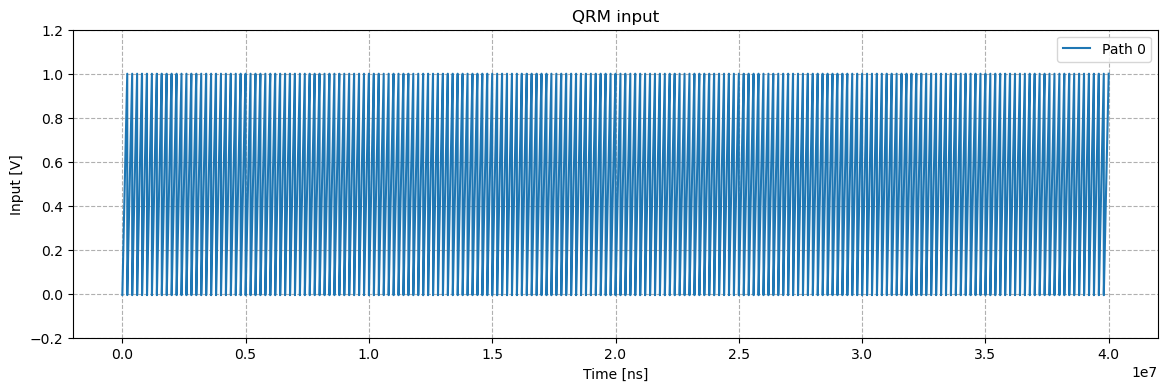

resolution in plot_input: 1000


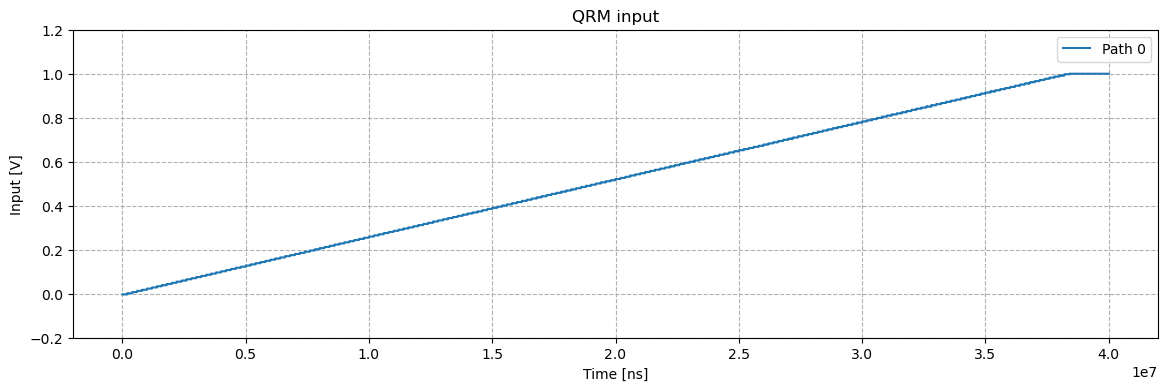

40000
40000
resolution in plot_input: 1000


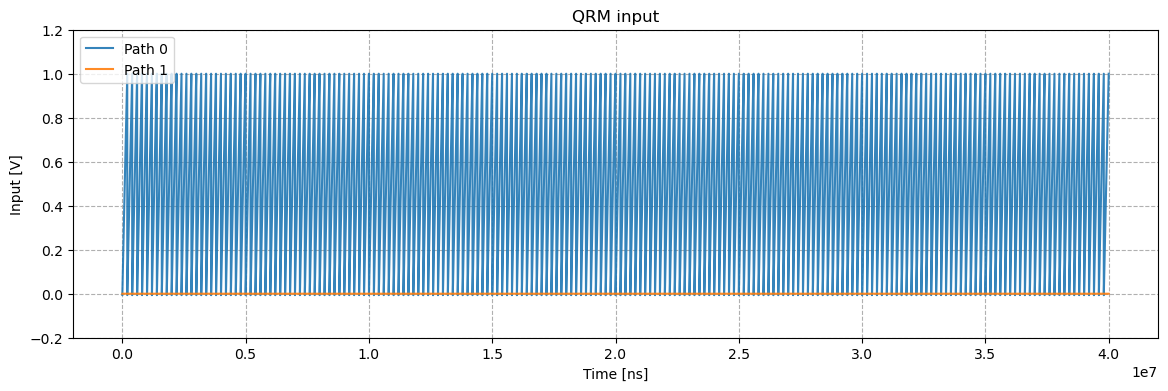

resolution in plot_input: 1000


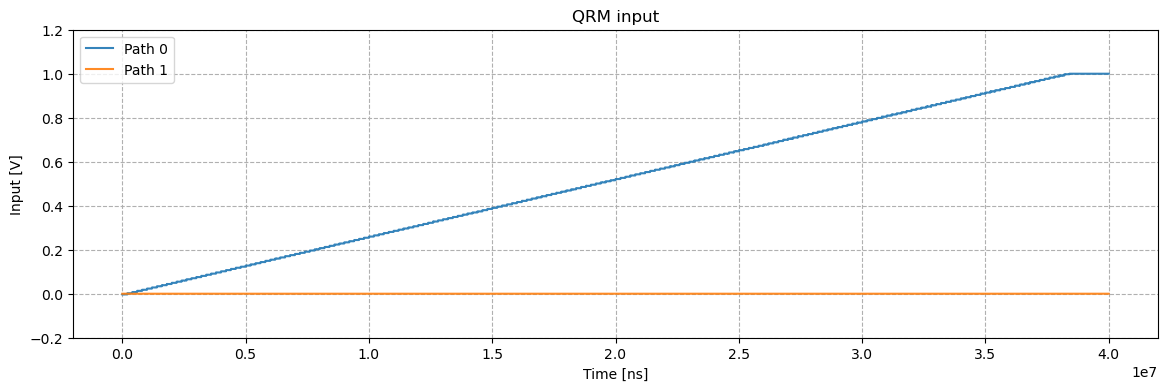

In [12]:
sh.plot_input(module = qrm_module, sequencer = 0, acquisition_name ='acq_0')
sh.plot_input(module = qrm_module, sequencer = 1, acquisition_name ='acq_1')
sh.plot_input_multi(module = qrm_module, sequencers = [0,1], acquisition_names = ['acq_0','acq_1'])